# Experiment 7: Dimensionality Reduction and Model Evaluation (With and Without PCA)

Comparative study evaluating 10 machine learning classifiers under original feature space (No-PCA) versus reduced feature space (With-PCA) on the Wisconsin Diagnostic Breast Cancer dataset.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

sns.set_style("whitegrid")
SEED_VAL = 42


## 1. Load Dataset and Explore Dimensions


In [2]:
cancer_dataset = load_breast_cancer()
X_features = pd.DataFrame(cancer_dataset.data, columns=cancer_dataset.feature_names)
y_target = pd.Series(cancer_dataset.target, name="diagnosis") # 0=malignant, 1=benign

print("Feature Matrix Dimensions:", X_features.shape)
print("Missing entries count:", X_features.isnull().sum().sum())
y_target.map({0: "malignant", 1: "benign"}).value_counts()


Feature Matrix Dimensions: (569, 30)
Missing entries count: 0


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

## 2. Stratified Split (80:20) and Standardization


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.20, stratify=y_target, random_state=SEED_VAL
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Train shape:", X_train_scaled.shape, " Scaled Test shape:", X_test_scaled.shape)


Scaled Train shape: (455, 30)  Scaled Test shape: (114, 30)


## 3. Principal Component Analysis (PCA) & Variance Target


In [4]:
# Fit PCA on full component spectrum for Scree Plot analysis
pca_full = PCA(random_state=SEED_VAL)
pca_full.fit(X_train_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# PCA targeting 95% variance
pca_95 = PCA(n_components=0.95, random_state=SEED_VAL)
X_train_pca = pca_95.fit_transform(X_train_scaled)
X_test_pca = pca_95.transform(X_test_scaled)

n_components_chosen = pca_95.n_components_
explained_var_pct = round(pca_95.explained_variance_ratio_.sum() * 100, 2)

print(f"Chosen PCA Components (95% target): {n_components_chosen}")
print(f"Total Variance Retained: {explained_var_pct}%")


Chosen PCA Components (95% target): 10
Total Variance Retained: 95.27%


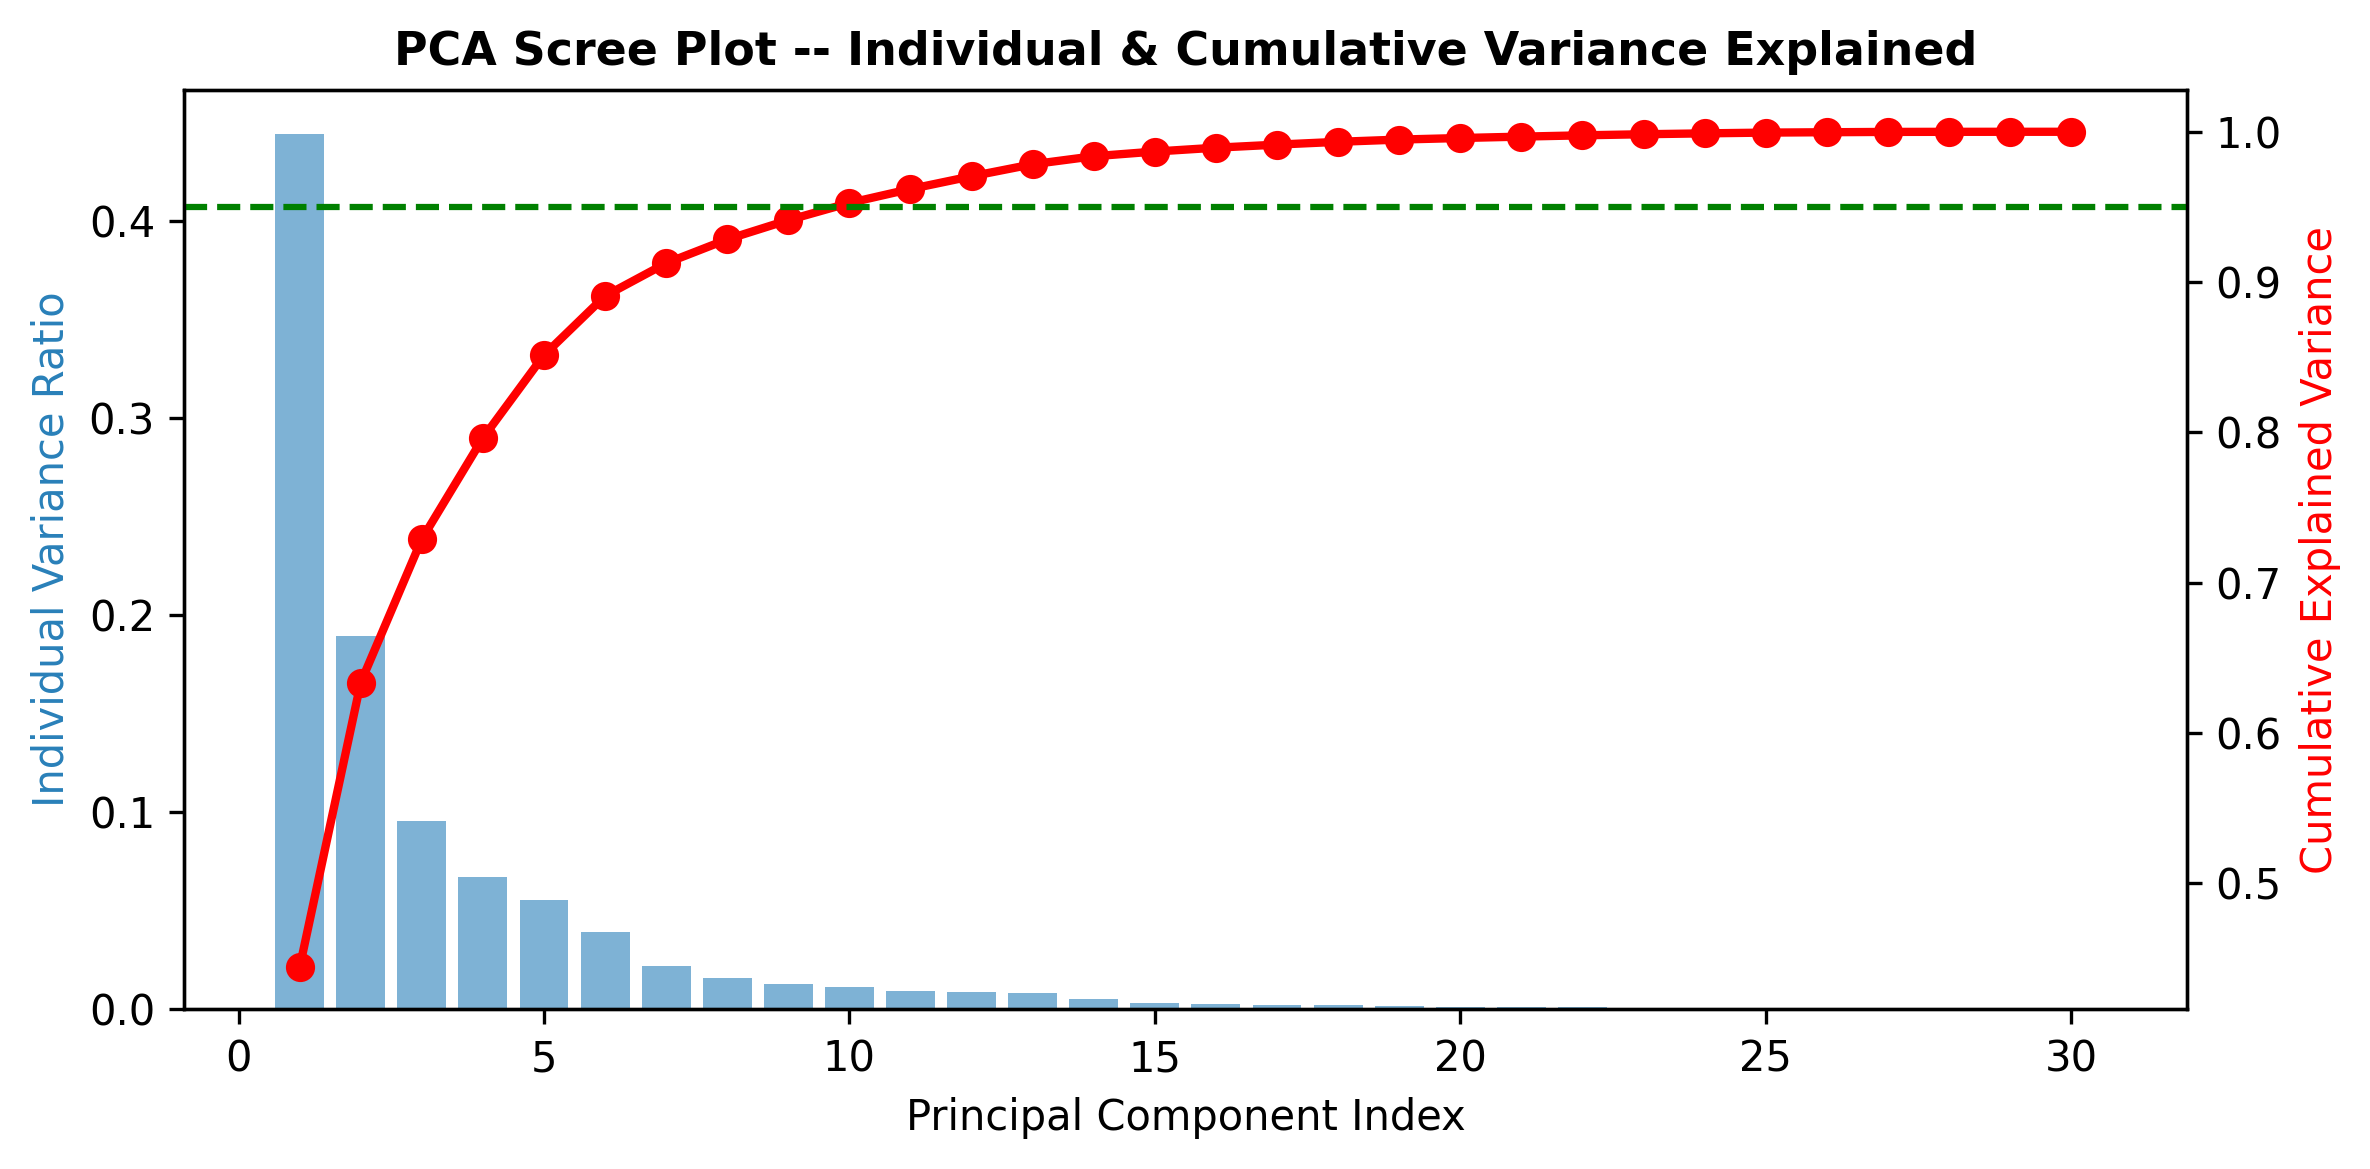

In [5]:
fig, ax1 = plt.subplots(figsize=(8, 4))
components_range = np.arange(1, len(explained_variance_ratio) + 1)

ax1.bar(components_range, explained_variance_ratio, alpha=0.6, color="#2980b9", label="Individual Variance")
ax1.set_xlabel("Principal Component Index")
ax1.set_ylabel("Individual Variance Ratio", color="#2980b9")

ax2 = ax1.twinx()
ax2.plot(components_range, cumulative_variance, "r-o", linewidth=2, label="Cumulative Variance")
ax2.set_ylabel("Cumulative Explained Variance", color="red")
ax2.axhline(y=0.95, color="green", linestyle="--", label="95% Threshold")

plt.title("PCA Scree Plot -- Individual & Cumulative Variance Explained", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("exp7_figures/scree_plot.png", dpi=300, bbox_inches="tight")
plt.show()


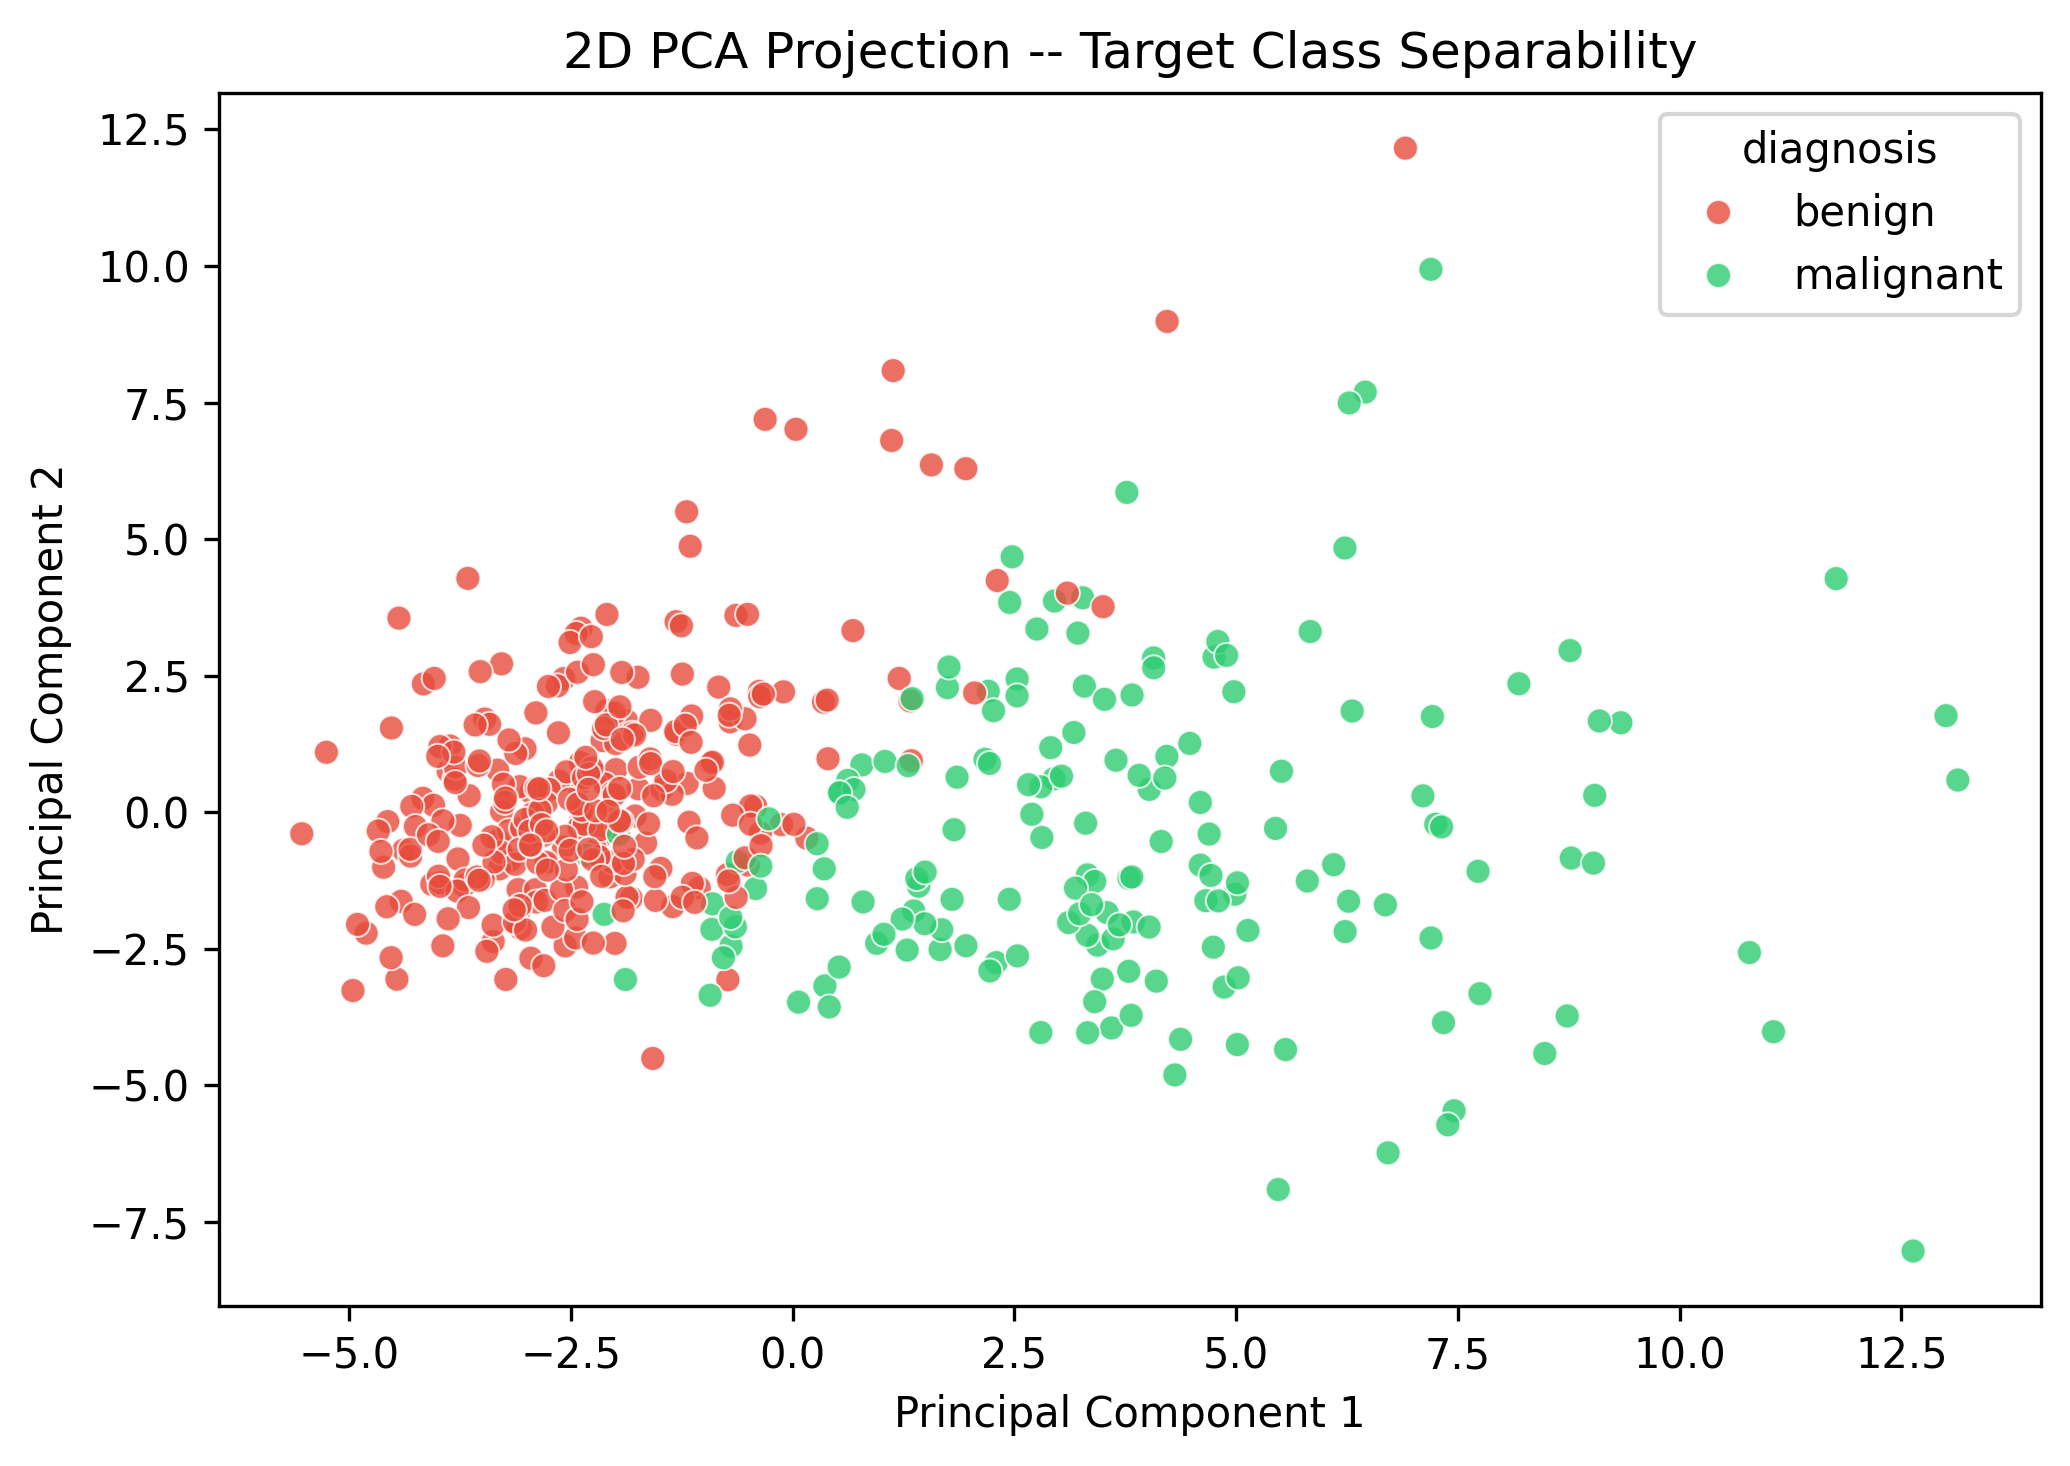

In [6]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train.map({0: "malignant", 1: "benign"}), palette=["#e74c3c", "#2ecc71"], alpha=0.8)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection -- Target Class Separability")
plt.tight_layout()
plt.savefig("exp7_figures/pca_2d_projection.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Evaluate 10 Classifiers (No-PCA vs With-PCA)


In [7]:
models_grid_dict = {
    "SVM": (SVC(probability=True, random_state=SEED_VAL), {
        "kernel": ["rbf", "linear"],
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"]
    }),
    "Naïve Bayes": (GaussianNB(), {
        "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
    }),
    "KNN": (KNeighborsClassifier(), {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    }),
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=SEED_VAL), {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    }),
    "Decision Tree": (DecisionTreeClassifier(random_state=SEED_VAL), {
        "max_depth": [3, 5, 7, None],
        "criterion": ["gini", "entropy"]
    }),
    "Random Forest": (RandomForestClassifier(random_state=SEED_VAL), {
        "n_estimators": [50, 100],
        "max_depth": [5, 10, None],
        "max_features": ["sqrt", "log2"]
    }),
    "AdaBoost": (AdaBoostClassifier(random_state=SEED_VAL), {
        "n_estimators": [50, 100],
        "learning_rate": [0.05, 0.1, 1.0]
    }),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=SEED_VAL), {
        "n_estimators": [50, 100],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    }),
    "XGBoost": (xgb.XGBClassifier(eval_metric="logloss", random_state=SEED_VAL), {
        "n_estimators": [50, 100],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    }),
    "Stacking": (StackingClassifier(
        estimators=[
            ("dt", DecisionTreeClassifier(max_depth=5, random_state=SEED_VAL)),
            ("nb", GaussianNB()),
            ("svm", SVC(probability=True, random_state=SEED_VAL))
        ],
        final_estimator=LogisticRegression(random_state=SEED_VAL),
        cv=5
    ), {})
}

cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED_VAL)


In [8]:
all_model_results = []
fold_details_list = []
best_estimators_map = {}

feature_settings = {
    "No-PCA": (X_train_scaled, X_test_scaled),
    "With-PCA": (X_train_pca, X_test_pca)
}

for m_name, (base_clf, param_grid) in models_grid_dict.items():
    for setting_label, (tr_x, te_x) in feature_settings.items():
        if param_grid:
            grid_obj = GridSearchCV(base_clf, param_grid=param_grid, cv=cv_5fold, scoring="accuracy", n_jobs=-1)
            grid_obj.fit(tr_x, y_train)
            best_model = grid_obj.best_estimator_
            best_params_str = str(grid_obj.best_params_)
        else:
            best_model = base_clf
            best_model.fit(tr_x, y_train)
            best_params_str = "Default / Ensembled"
            
        best_estimators_map[(m_name, setting_label)] = best_model
        
        # Calculate 5-fold CV scores
        cv_scores = cross_val_score(best_model, tr_x, y_train, cv=cv_5fold, scoring="accuracy")
        
        # Predict on Test set
        test_pred = best_model.predict(te_x)
        if hasattr(best_model, "predict_proba"):
            test_prob = best_model.predict_proba(te_x)[:, 1]
        elif hasattr(best_model, "decision_function"):
            test_prob = best_model.decision_function(te_x)
        else:
            test_prob = test_pred
            
        acc = accuracy_score(y_test, test_pred)
        prec = precision_score(y_test, test_pred)
        rec = recall_score(y_test, test_pred)
        f1 = f1_score(y_test, test_pred)
        auc = roc_auc_score(y_test, test_prob)
        
        all_model_results.append({
            "Model": m_name,
            "Setting": setting_label,
            "Best_Params": best_params_str,
            "CV_Avg": cv_scores.mean(),
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1_Score": f1,
            "ROC_AUC": auc
        })
        
        fold_row = [m_name, setting_label] + list(cv_scores.round(4)) + [round(cv_scores.mean(), 4)]
        fold_details_list.append(fold_row)

summary_df = pd.DataFrame(all_model_results)
fold_df = pd.DataFrame(fold_details_list, columns=["Model", "Setting", "Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5", "Avg CV"])
print("Evaluation loop completed successfully for all 10 models!")


Evaluation loop completed successfully for all 10 models!


## 5. Consolidated Model Evaluation & 5-Fold Cross-Validation Summary


In [9]:
pivot_cv = summary_df.pivot(index="Model", columns="Setting", values="CV_Avg").round(4)
pivot_cv["Difference (With - No)"] = (pivot_cv["With-PCA"] - pivot_cv["No-PCA"]).round(4)
pivot_cv


Setting,No-PCA,With-PCA,Difference (With - No)
Model,,,
AdaBoost,0.9802,0.9516,-0.0286
Decision Tree,0.9319,0.9297,-0.0022
Gradient Boosting,0.9516,0.9495,-0.0021
KNN,0.9714,0.9648,-0.0066
Logistic Regression,0.9824,0.9824,0.0000
Naïve Bayes,0.9341,0.9165,-0.0176
Random Forest,0.9648,0.9560,-0.0088
SVM,0.9758,0.9780,0.0022
Stacking,0.9670,0.9648,-0.0022


In [10]:
fold_df


,Model,Setting,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Avg CV
0,SVM,No-PCA,0.9560,0.9780,0.9780,0.9780,0.9890,0.9758
1,SVM,With-PCA,0.9560,0.9890,0.9890,0.9780,0.9780,0.9780
2,Naïve Bayes,No-PCA,0.9121,0.9670,0.8901,0.9560,0.9451,0.9341
3,Naïve Bayes,With-PCA,0.8791,0.9341,0.9121,0.9341,0.9231,0.9165
4,KNN,No-PCA,0.9780,0.9890,0.9560,0.9560,0.9780,0.9714
5,KNN,With-PCA,0.9560,0.9890,0.9451,0.9560,0.9780,0.9648
6,Logistic Regression,No-PCA,0.9780,0.9780,0.9890,0.9780,0.9890,0.9824
7,Logistic Regression,With-PCA,0.9780,0.9780,0.9890,0.9780,0.9890,0.9824
8,Decision Tree,No-PCA,0.9011,0.9451,0.9121,0.9341,0.9670,0.9319
9,Decision Tree,With-PCA,0.9121,0.9231,0.9231,0.9670,0.9231,0.9297


## 6. Visual Comparisons: No-PCA vs With-PCA Across All 10 Models


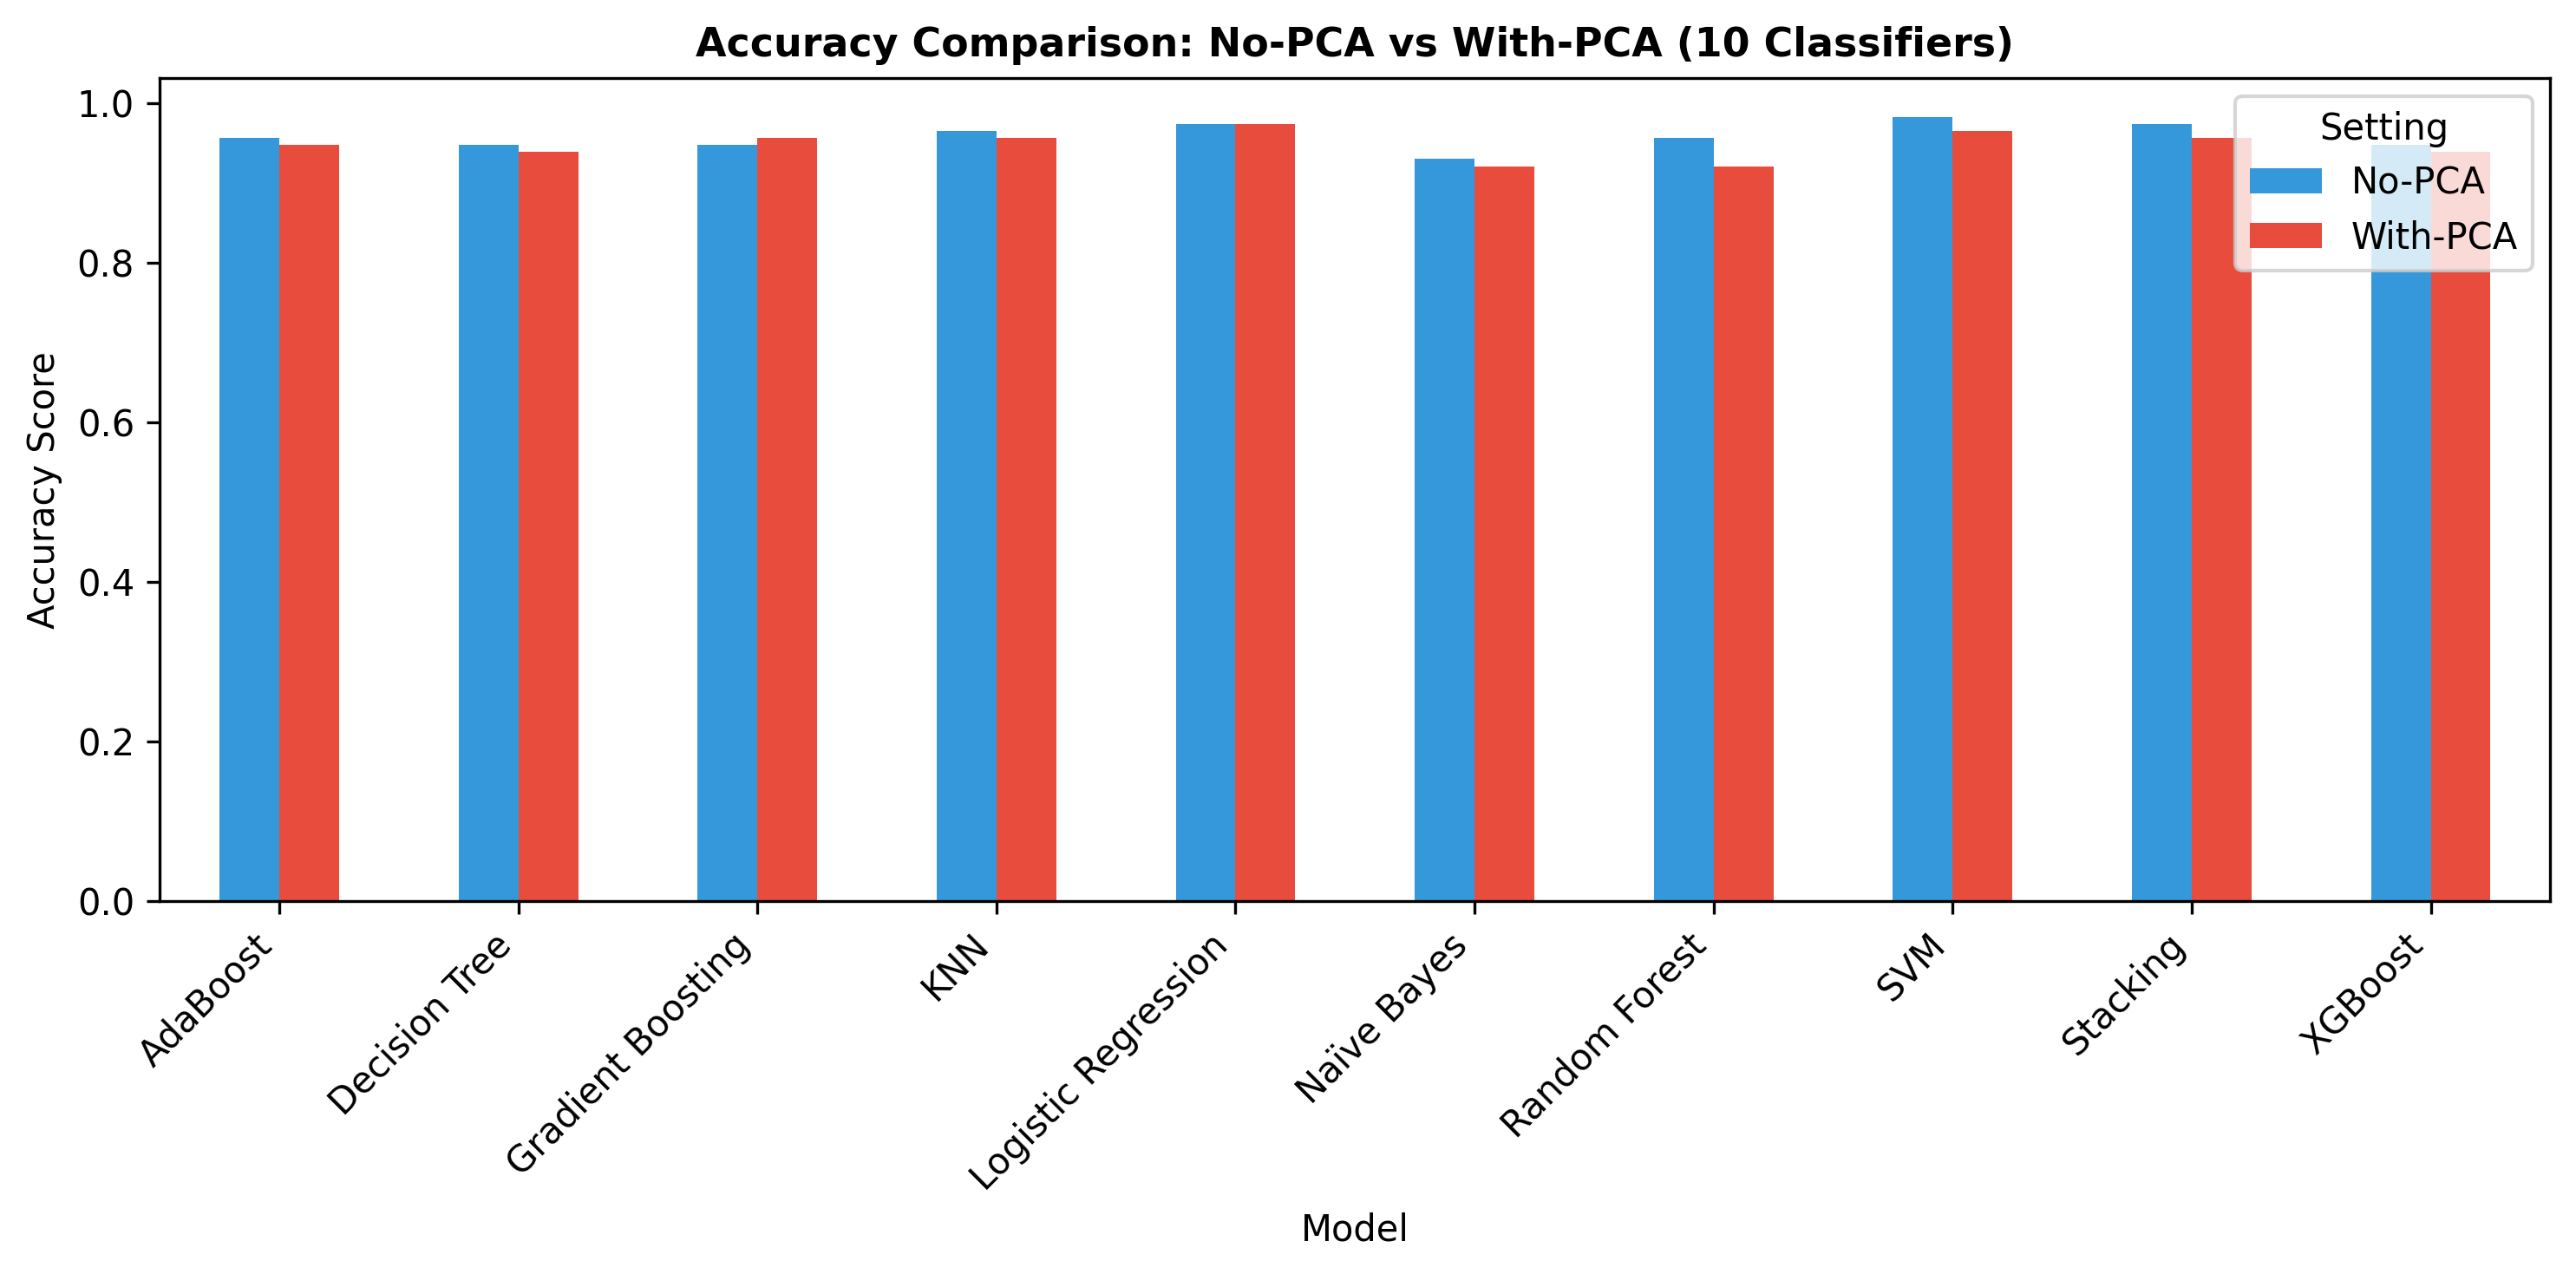

In [11]:
pivot_acc = summary_df.pivot(index="Model", columns="Setting", values="Accuracy")
fig, ax = plt.subplots(figsize=(10, 5))
pivot_acc.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"])
ax.set_title("Accuracy Comparison: No-PCA vs With-PCA (10 Classifiers)", fontsize=11, fontweight="bold")
ax.set_ylabel("Accuracy Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Setting")
plt.tight_layout()
plt.savefig("exp7_figures/cv_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


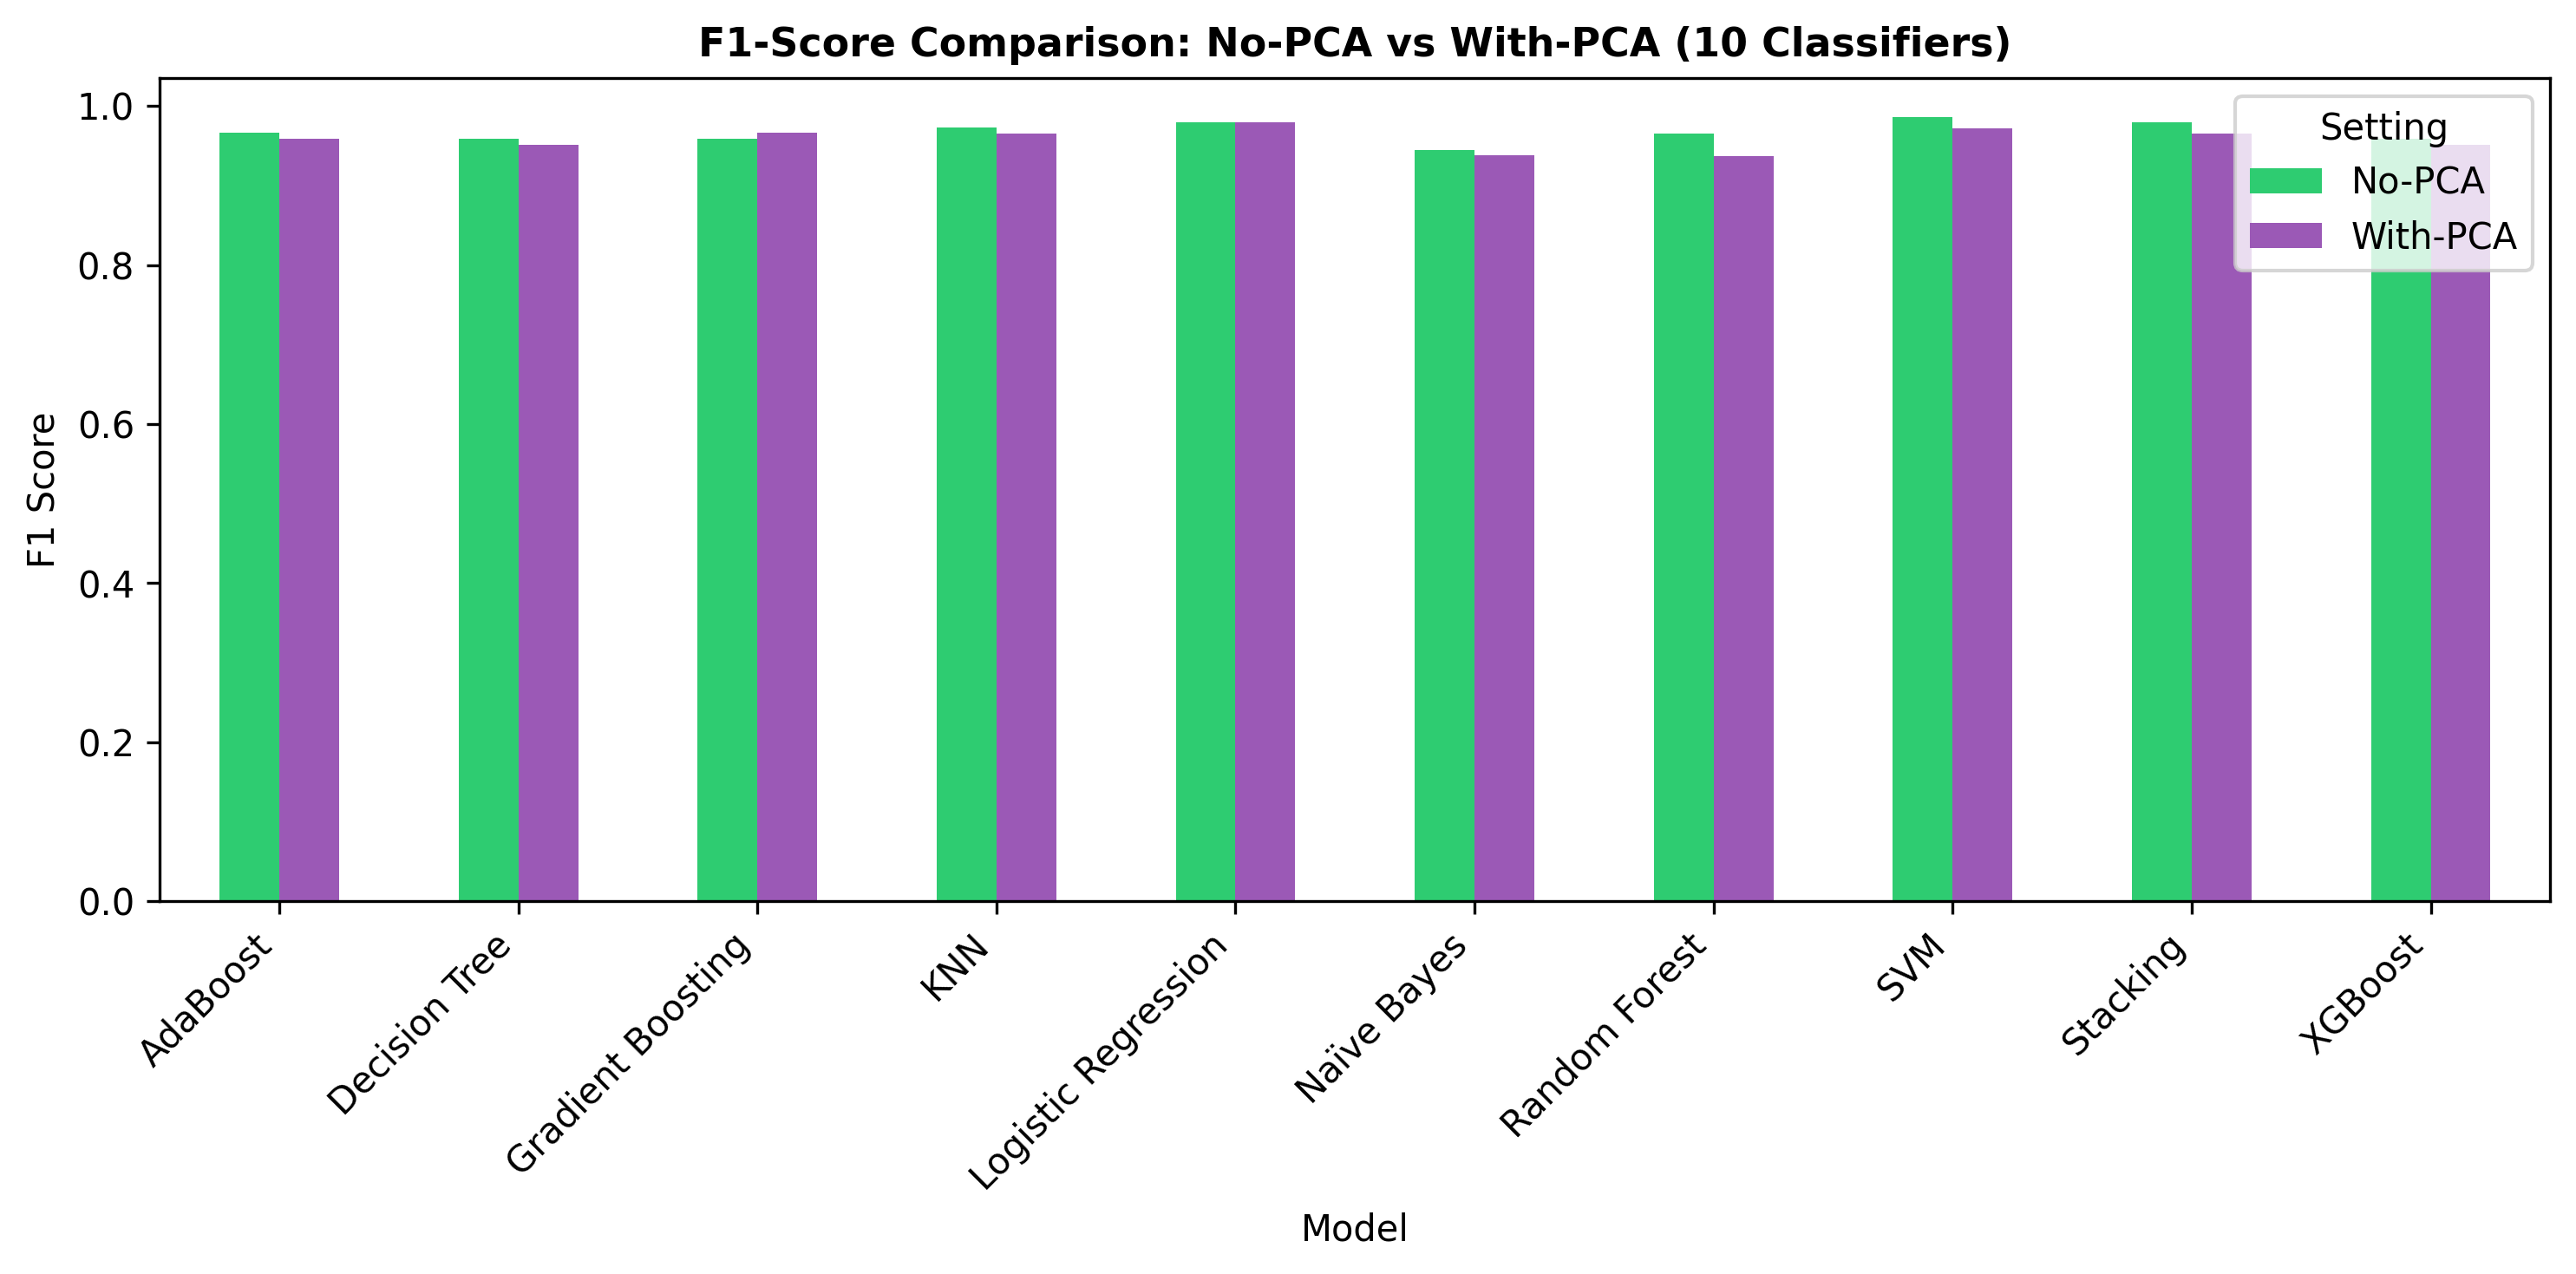

In [12]:
pivot_f1 = summary_df.pivot(index="Model", columns="Setting", values="F1_Score")
fig, ax = plt.subplots(figsize=(10, 5))
pivot_f1.plot(kind="bar", ax=ax, color=["#2ecc71", "#9b59b6"])
ax.set_title("F1-Score Comparison: No-PCA vs With-PCA (10 Classifiers)", fontsize=11, fontweight="bold")
ax.set_ylabel("F1 Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Setting")
plt.tight_layout()
plt.savefig("exp7_figures/f1_score_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Confusion Matrices and ROC Curves for Selected Top Models


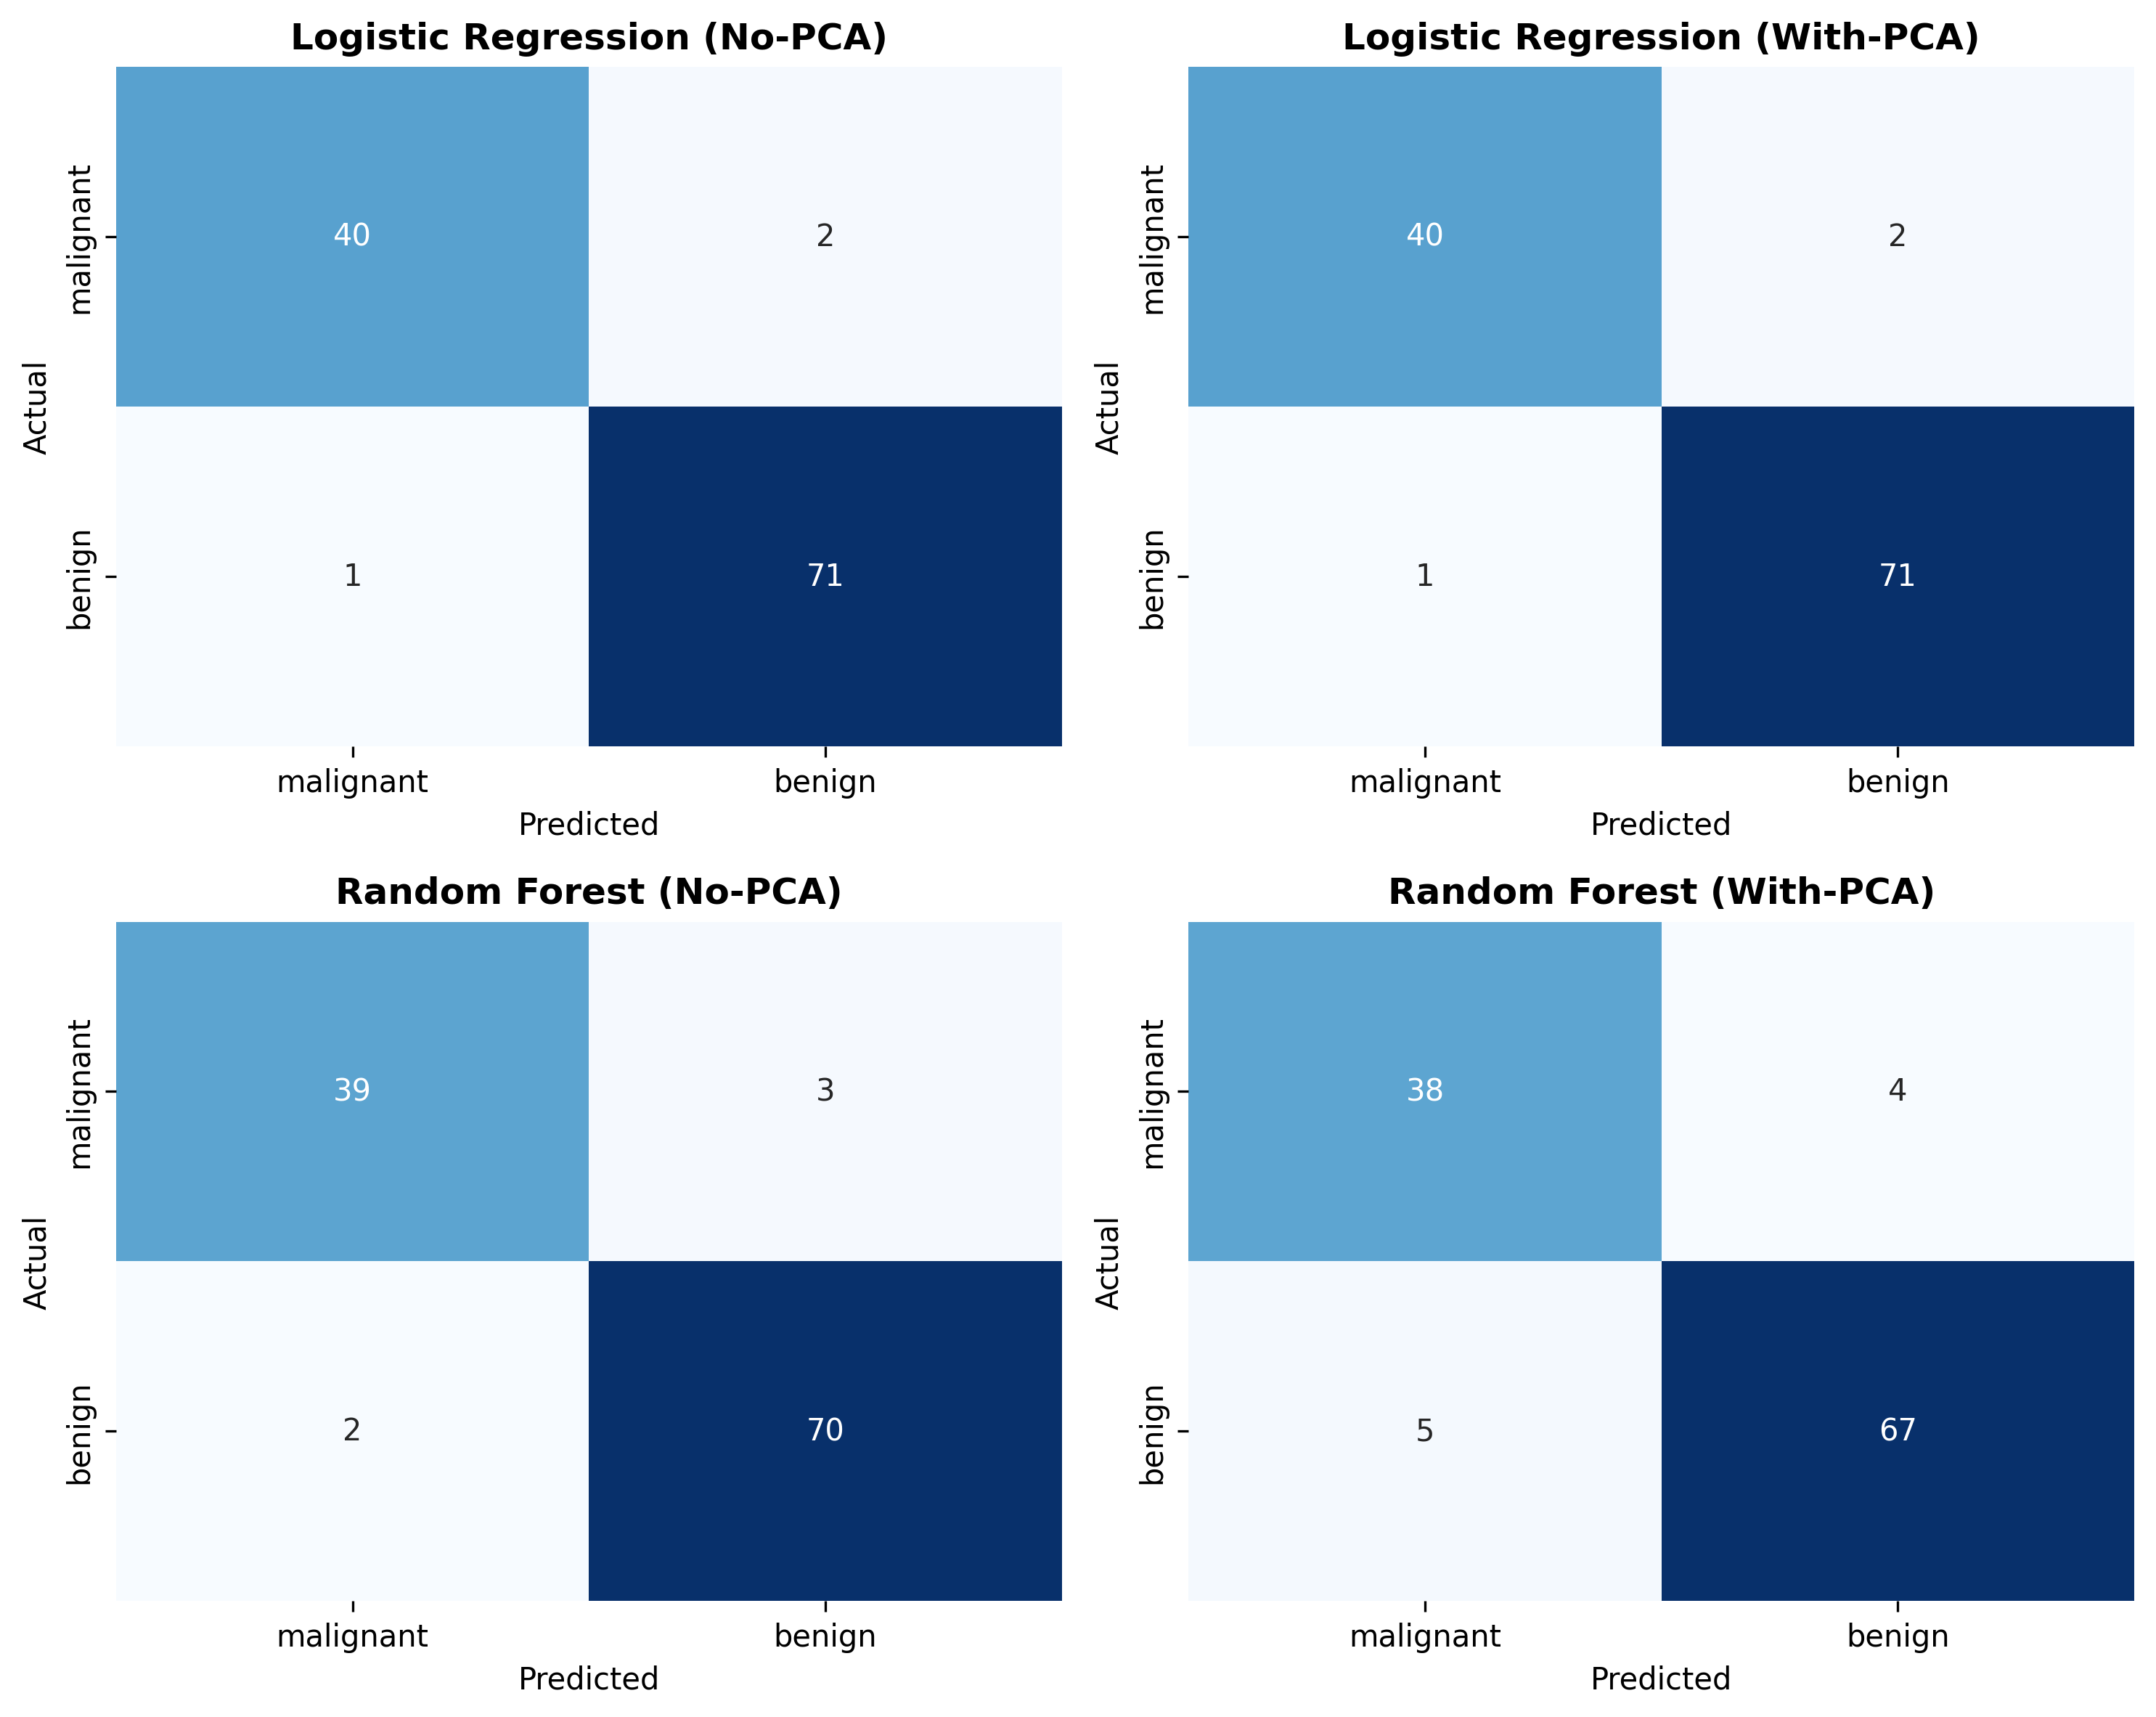

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
selected_models = [("Logistic Regression", "No-PCA"), ("Logistic Regression", "With-PCA"),
                   ("Random Forest", "No-PCA"), ("Random Forest", "With-PCA")]

for (m_name, s_label), ax in zip(selected_models, axes.flatten()):
    mod = best_estimators_map[(m_name, s_label)]
    te_x = X_test_scaled if s_label == "No-PCA" else X_test_pca
    pred = mod.predict(te_x)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["malignant", "benign"], yticklabels=["malignant", "benign"])
    ax.set_title(f"{m_name} ({s_label})", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("exp7_figures/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()


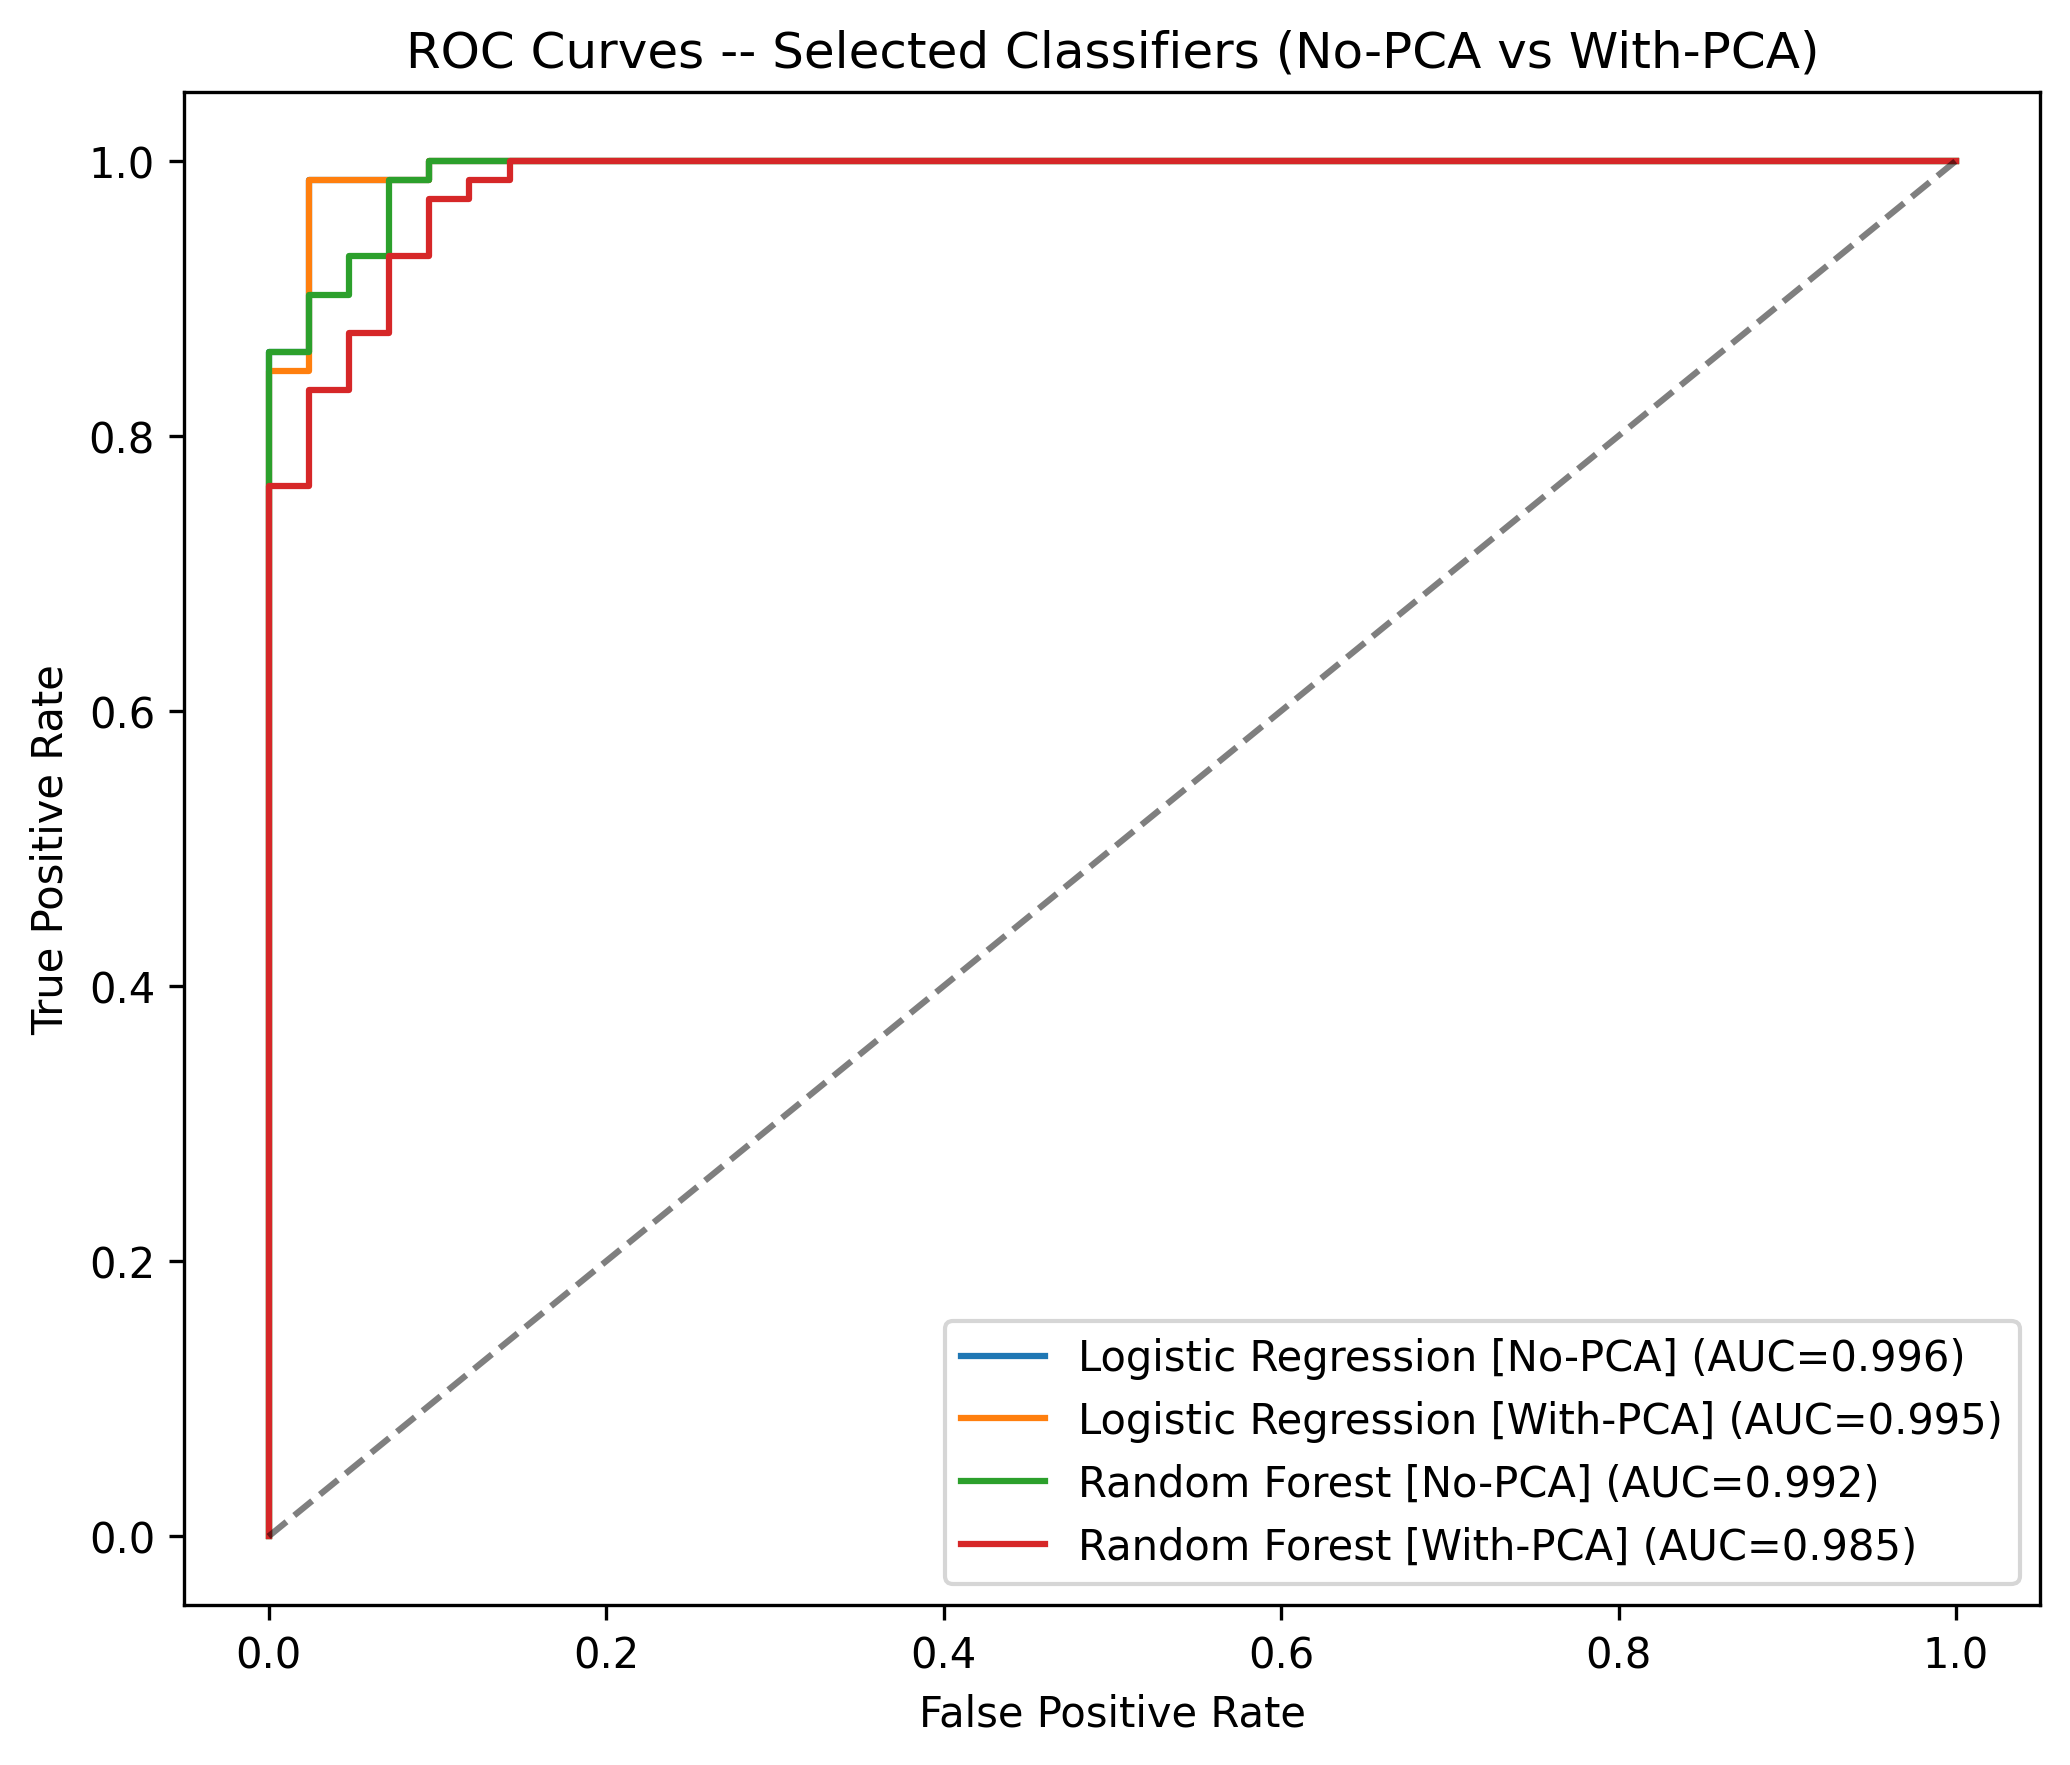

In [14]:
plt.figure(figsize=(7, 6))

for (m_name, s_label) in selected_models:
    mod = best_estimators_map[(m_name, s_label)]
    te_x = X_test_scaled if s_label == "No-PCA" else X_test_pca
    if hasattr(mod, "predict_proba"):
        prob = mod.predict_proba(te_x)[:, 1]
    else:
        prob = mod.decision_function(te_x)
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{m_name} [{s_label}] (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves -- Selected Classifiers (No-PCA vs With-PCA)")
plt.legend()
plt.tight_layout()
plt.savefig("exp7_figures/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()


## Summary & Key Observations

See the accompanying report (`Experiment7.pdf` / `Experiment7.tex`) for complete theoretical analysis, detailed responses to observation questions, fold-by-fold results tables, and comprehensive conclusions on PCA feature space reduction.
